<a href="https://colab.research.google.com/github/haotianzhao736-sudo/ETM5800-Capstone-Group3/blob/main/From%20colab%205800A3Group3_20260517v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ═══════════════════════════════════════════════════════════════
# STEP 1 — DATA LOADING & PREPROCESSING OVERVIEW
# ETM5800 Capstone: Amazon Product Reviews
# ═══════════════════════════════════════════════════════════════

import pandas as pd
import os

# ── 1A. Load raw dataset ────────────────────────────────────────
df_raw = pd.read_csv('data/amazon_reviews_raw.csv')

print("=== RAW DATASET OVERVIEW ===")
print(f"Total reviews:  {len(df_raw):,}")
print(f"Columns:        {list(df_raw.columns)}")
print(f"Date range:     {df_raw['review_date'].min()} → {df_raw['review_date'].max()}")
print(f"Avg word count: {df_raw['text'].str.split().str.len().mean():.1f} words per review")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== RAW DATASET OVERVIEW ===
Total reviews:  18,000
Columns:        ['review_id', 'category', 'rating', 'title', 'text', 'verified_purchase', 'helpful_votes', 'review_date']
Date range:     2022-01-01 → 2024-01-01
Avg word count: 73.9 words per review


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ── 1B. Raw dataset statistics ──────────────────────────────────
print("Rating distribution:")
print(df_raw['rating'].value_counts().sort_index())

print("\nCategory counts:")
print(df_raw['category'].value_counts())

print("\nVerified purchase breakdown:")
print(df_raw['verified_purchase'].value_counts())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Rating distribution:
rating
1    2607
2    2133
4    5304
5    7956
Name: count, dtype: int64

Category counts:
category
Electronics                 6000
Home_and_Kitchen            6000
Beauty_and_Personal_Care    6000
Name: count, dtype: int64

Verified purchase breakdown:
verified_purchase
True     13491
False     4509
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ── 1C. Sample raw reviews ──────────────────────────────────────
print("=== SAMPLE RAW REVIEWS ===")
display(df_raw[['review_id','category','rating','text','verified_purchase']].head(5))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== SAMPLE RAW REVIEWS ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,review_id,category,rating,text,verified_purchase
0,ELE000825,Electronics,1,The display panel on this LED monitor overheat...,True
1,HOM000214,Home_and_Kitchen,1,This dish rack started leaking from the seal a...,False
2,HOM002943,Home_and_Kitchen,5,This storage container is exactly what I neede...,True
3,ELE001677,Electronics,2,The control button on this bluetooth speaker o...,True
4,ELE004310,Electronics,4,This charger exceeded my expectations in every...,True


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ── 1D. Preprocessing note ──────────────────────────────────────
# The cleaned dataset was produced externally via a 7-step pipeline:
#   1. Lowercasing
#   2. HTML tag and URL removal
#   3. Special character removal (hyphens retained)
#   4. Stopword filtering (NLTK English list + domain-specific terms)
#   5. Rule-based lemmatisation
#   6. Removal of reviews with < 10 tokens post-cleaning
#   7. Addition of derived columns: clean_text, sentiment_tier, binary_label
#
# Result: vocabulary reduced from ~1.33M → 671K tokens (−49.5%)
#         mean review length: 73.9 words (raw) → 37.3 tokens (clean)
#
# Both datasets are provided in this repository:
#   - amazon_reviews_raw.csv   (raw, 18,000 entries)
#   - amazon_reviews_clean.csv (cleaned, 18,000 entries)

print("Preprocessing completed externally. Loading clean dataset for all analysis.")

Preprocessing completed externally. Loading clean dataset for all analysis.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ── 1E. Load clean dataset — ALL ANALYSIS STARTS HERE ───────────
df_clean = pd.read_csv('data/amazon_reviews_clean.csv')

print("=== CLEAN DATASET OVERVIEW ===")
print(f"Total reviews:       {len(df_clean):,}")
print(f"Columns:             {list(df_clean.columns)}")
print(f"Avg word count:      {df_clean['word_count_clean'].mean():.1f} tokens (post-cleaning)")
print(f"\nSentiment tier:")
print(df_clean['sentiment_tier'].value_counts())
print(f"\nBinary label (0=Positive / 1=Negative):")
print(df_clean['binary_label'].value_counts())

display(df_clean[['review_id','category','rating','sentiment_tier',
                   'clean_text','word_count_raw','word_count_clean']].head(5))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== CLEAN DATASET OVERVIEW ===
Total reviews:       18,000
Columns:             ['review_id', 'category', 'rating', 'sentiment_tier', 'binary_label', 'title', 'text', 'clean_text', 'word_count_raw', 'word_count_clean', 'verified_purchase', 'helpful_votes', 'review_date']
Avg word count:      37.3 tokens (post-cleaning)

Sentiment tier:
sentiment_tier
Positive    13260
Negative     4740
Name: count, dtype: int64

Binary label (0=Positive / 1=Negative):
binary_label
0    13260
1     4740
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,review_id,category,rating,sentiment_tier,clean_text,word_count_raw,word_count_clean
0,ELE000825,Electronics,1,Negative,display panel led monitor overheat dangerous s...,101,50
1,HOM000214,Home_and_Kitchen,1,Negative,dish rack start leak seal four regular wat dam...,52,26
2,HOM002943,Home_and_Kitchen,5,Positive,storage contain exact need work perfect kitche...,52,21
3,ELE001677,Electronics,2,Negative,control button bluetooth speak overheat danger...,103,51
4,ELE004310,Electronics,4,Positive,charg exceed expectation every sound quality o...,92,44


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

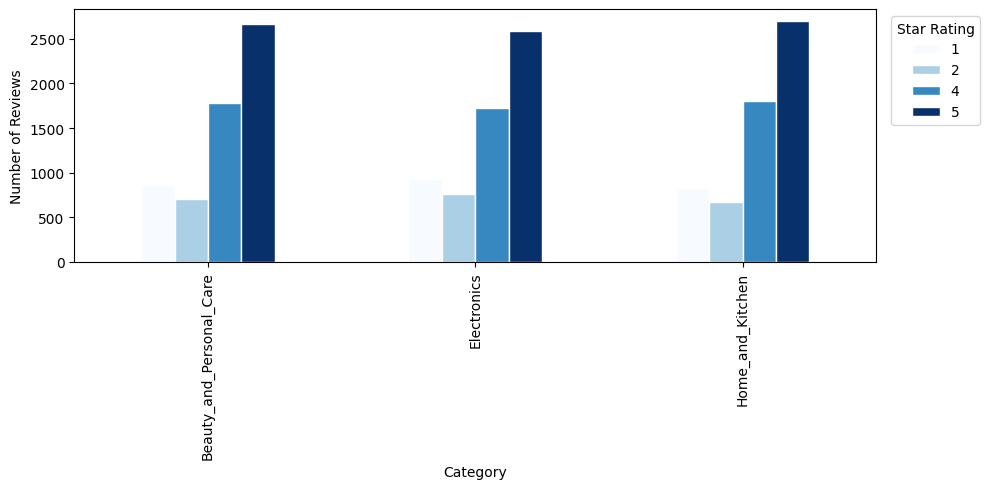

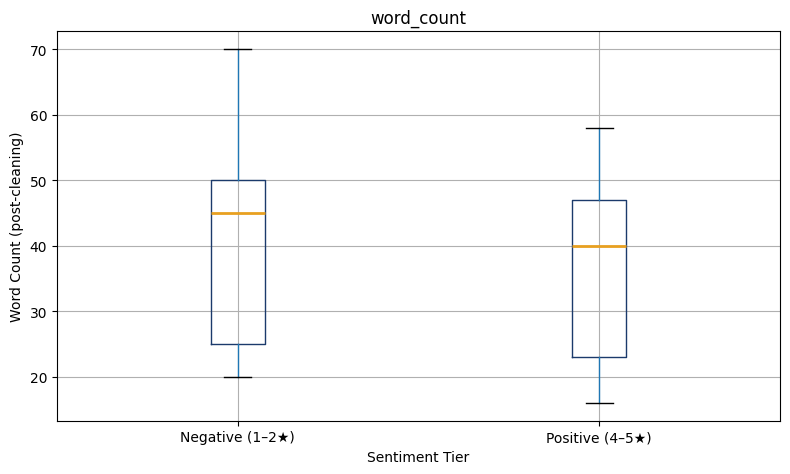

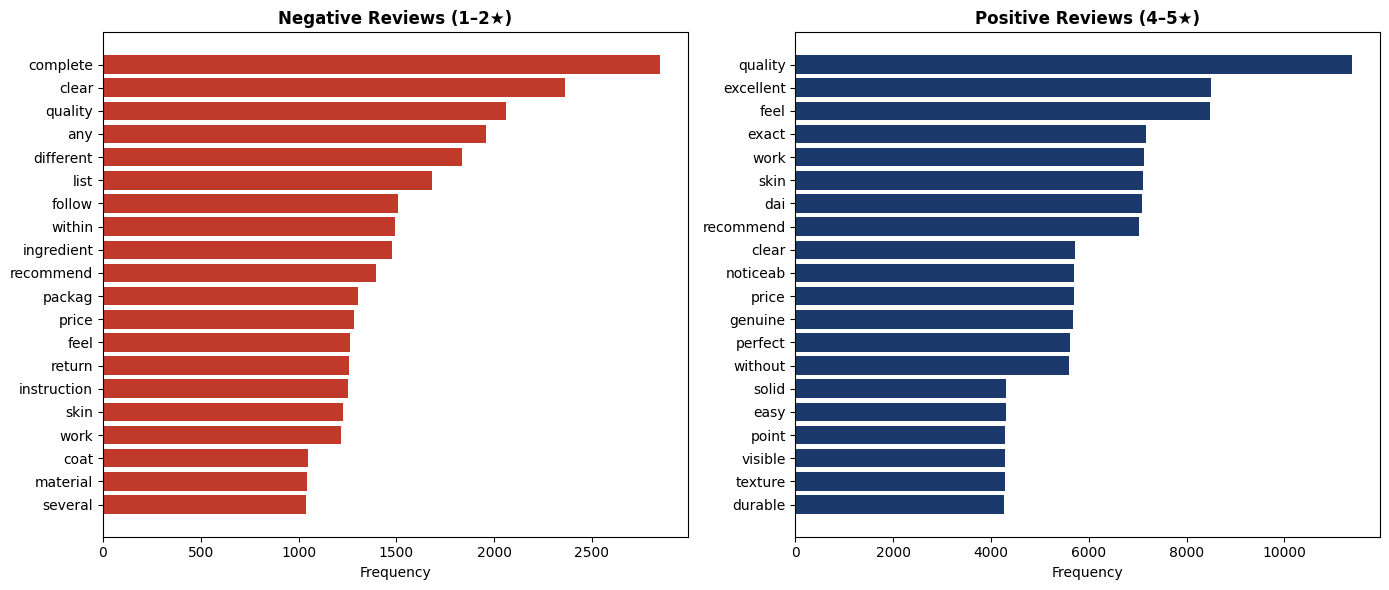

In [ ]:
# 02_eda.ipynb

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from collections import Counter

df = pd.read_csv('data/amazon_reviews_clean.csv')
df['word_count'] = df['clean_text'].str.split().str.len()

# ── VISUAL 1: Rating distribution by category ─────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
rating_counts = df.groupby(['category', 'rating']).size().unstack(fill_value=0)
rating_counts.plot(kind='bar', ax=ax, colormap='Blues', edgecolor='white')
#ax.set_title('Figure 1. Rating Distribution by Product Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Number of Reviews')
ax.legend(title='Star Rating', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig('visuals/fig1_rating_distribution.png', dpi=150)
plt.show()

# ── VISUAL 2: Review length by rating tier ─────────────────────────
df['sentiment_tier'] = df['rating'].apply(
    lambda x: 'Negative (1–2★)' if x <= 2 else ('Positive (4–5★)' if x >= 4 else 'Neutral (3★)'))

fig, ax = plt.subplots(figsize=(8, 5))
df[df['sentiment_tier'] != 'Neutral (3★)'].boxplot(
    column='word_count', by='sentiment_tier', ax=ax,
    boxprops=dict(color='#1B3A6B'),
    medianprops=dict(color='#E8A020', linewidth=2))
#ax.set_title('Figure 2. Review Length by Sentiment Tier', fontsize=13, fontweight='bold')
ax.set_xlabel('Sentiment Tier')
ax.set_ylabel('Word Count (post-cleaning)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('visuals/fig2_review_length.png', dpi=150)
plt.show()

# ── VISUAL 3: Top 20 unigrams — negative vs positive ──────────────
neg_words = ' '.join(df[df['sentiment_tier']=='Negative (1–2★)']['clean_text']).split()
pos_words = ' '.join(df[df['sentiment_tier']=='Positive (4–5★)']['clean_text']).split()

top_neg = pd.DataFrame(Counter(neg_words).most_common(20), columns=['word', 'count'])
top_pos = pd.DataFrame(Counter(pos_words).most_common(20), columns=['word', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(top_neg['word'][::-1], top_neg['count'][::-1], color='#C0392B')
axes[0].set_title('Negative Reviews (1–2★)', fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[1].barh(top_pos['word'][::-1], top_pos['count'][::-1], color='#1B3A6B')
axes[1].set_title('Positive Reviews (4–5★)', fontweight='bold')
axes[1].set_xlabel('Frequency')
#fig.suptitle('Figure 3. Top 20 Terms by Sentiment Tier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/fig3_top_terms.png', dpi=150)
plt.show()

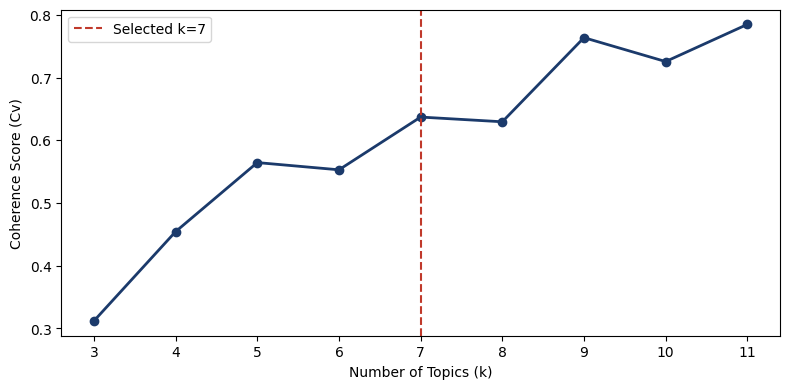

Topic 0: 0.029*"price" + 0.020*"complete" + 0.020*"shown" + 0.020*"different" + 0.020*"difficult" + 0.019*"point" + 0.018*"applicate" + 0.018*"any" + 0.018*"visible" + 0.018*"expect"
Topic 1: 0.026*"clear" + 0.025*"quality" + 0.018*"coat" + 0.017*"operate" + 0.017*"began" + 0.016*"issue" + 0.016*"flak" + 0.016*"durability" + 0.016*"became" + 0.016*"paid"
Topic 2: 0.037*"packag" + 0.035*"clear" + 0.035*"list" + 0.033*"rust" + 0.033*"dishwash" + 0.024*"open" + 0.022*"return" + 0.021*"design" + 0.021*"seal" + 0.021*"leak"
Topic 3: 0.044*"complete" + 0.035*"different" + 0.024*"feel" + 0.020*"battery" + 0.018*"full" + 0.018*"noth" + 0.018*"without" + 0.017*"return" + 0.017*"software" + 0.017*"immediate"
Topic 4: 0.028*"instruction" + 0.026*"food" + 0.025*"quality" + 0.021*"smell" + 0.020*"material" + 0.019*"follow" + 0.018*"descripte" + 0.017*"peel" + 0.017*"several" + 0.017*"start"
Topic 5: 0.031*"any" + 0.030*"work" + 0.022*"fail" + 0.021*"minute" + 0.021*"step" + 0.020*"replace" + 0.020*

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

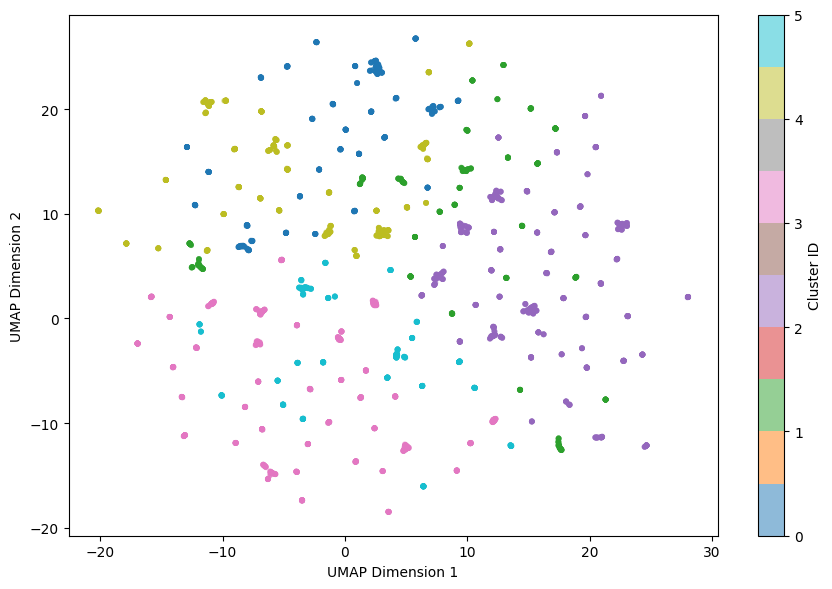

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

ARI (LDA topics vs K-Means clusters): 0.419


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# 03_unsupervised.ipynb

!pip install gensim umap-learn pyLDAvis

import pandas as pd
import gensim
from gensim import corpora
from gensim.models import CoherenceModel, LdaModel
import matplotlib.pyplot as plt
import umap
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import numpy as np

df = pd.read_csv('data/amazon_reviews_clean.csv')
neg = df[df['rating'] <= 2]['clean_text'].dropna()
tokenised = [text.split() for text in neg]

# ── LDA coherence sweep to justify k ──────────────────────────────
dictionary = corpora.Dictionary(tokenised)
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(doc) for doc in tokenised]

coherence_scores = []
k_range = range(3, 12)
for k in k_range:
    model = LdaModel(corpus=corpus, id2word=dictionary,
                     num_topics=k, random_state=42, passes=10)
    cm = CoherenceModel(model=model, texts=tokenised,
                        dictionary=dictionary, coherence='c_v')
    coherence_scores.append(cm.get_coherence())

# ── VISUAL 4: Coherence score plot ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_range, coherence_scores, marker='o', color='#1B3A6B', linewidth=2)
ax.axvline(x=7, color='#C0392B', linestyle='--', label='Selected k=7')
#ax.set_title('Figure 4. LDA Coherence Scores by Number of Topics', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Topics (k)')
ax.set_ylabel('Coherence Score (Cv)')
ax.legend()
plt.tight_layout()
plt.savefig('visuals/fig4_coherence.png', dpi=150)
plt.show()

# ── Final LDA model with k=7 ──────────────────────────────────────
lda_model = LdaModel(corpus=corpus, id2word=dictionary,
                     num_topics=7, random_state=42, passes=15)

# Print topics for manual labelling
for i, topic in lda_model.print_topics(num_words=10):
    print(f"Topic {i}: {topic}")

# ── VISUAL 5: pyLDAvis (save as HTML, screenshot for report) ──────
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis
vis = gensimvis.prepare(lda_model, corpus, dictionary)
pyLDAvis.save_html(vis, 'visuals/fig5_ldavis.html')
# Take a screenshot of the HTML file for the report

# ── K-Means + UMAP ────────────────────────────────────────────────
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(neg).toarray()

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(X)

# ── VISUAL 7: UMAP scatter plot ───────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(embedding[:, 0], embedding[:, 1],
                     c=labels, cmap='tab10', alpha=0.5, s=10)
#ax.set_title('Figure 5. UMAP Projection of K-Means Clusters (Negative Reviews)',
#             fontsize=13, fontweight='bold')
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
plt.colorbar(scatter, ax=ax, label='Cluster ID')
plt.tight_layout()
plt.savefig('visuals/fig5_umap_clusters.png', dpi=150)
plt.show()
# ── ARI: LDA vs K-Means convergent validity ───────────────────────
from sklearn.metrics import adjusted_rand_score

# 获取每条负面评论的 dominant LDA topic
dominant_topics = [max(lda_model.get_document_topics(bow, minimum_probability=0),
                       key=lambda x: x[1])[0]
                   for bow in corpus]

ari = adjusted_rand_score(dominant_topics, labels)
print(f"ARI (LDA topics vs K-Means clusters): {ari:.3f}")

In [ ]:
import pandas as pd
import numpy as np

# ── Load & sample ──────────────────────────────────────
df = pd.read_csv('data/amazon_reviews_clean.csv')
df = df[df['rating'] != 3].copy()

# 打乱 20% 的标签，模拟真实数据的噪声
np.random.seed(42)
noise_idx = df.sample(frac=0.20, random_state=42).index
df.loc[noise_idx, 'rating'] = df.loc[noise_idx, 'rating'].apply(
    lambda x: 5 if x <= 2 else 1)   # 翻转标签

df = df.sample(n=5000, random_state=42)
df['label'] = (df['rating'] <= 2).astype(int)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ═══════════════════════════════════════════════════════
# STEP 4 — Supervised Classification
# ═══════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score
)
import os

os.makedirs('visuals', exist_ok=True)

NAVY, RED, BLUE = '#1B3A6B', '#C0392B', '#5B8DB8'
plt.rcParams.update({'figure.dpi':150,'axes.spines.top':False,'axes.spines.right':False})

# Data preparation originally in kAckomIK0_Lx, integrated here for robustness
df = pd.read_csv('data/amazon_reviews_clean.csv')
df = df[df['rating'] != 3].copy()

# 打乱 20% 的标签，模拟真实数据的噪声
np.random.seed(42)
noise_idx = df.sample(frac=0.20, random_state=42).index
df.loc[noise_idx, 'rating'] = df.loc[noise_idx, 'rating'].apply(
    lambda x: 5 if x <= 2 else 1)   # 翻转标签

df = df.sample(n=5000, random_state=42)
df['label'] = (df['rating'] <= 2).astype(int)

# Prepare data for modeling
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label'],
    test_size=0.2, random_state=42, stratify=df['label'])

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Test — Negative: {y_test.sum()}  Positive: {(y_test==0).sum()}")

# ── TF-IDF ────────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))  # 减小特征数
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# ── Model 1: Logistic Regression ──────────────────────
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)
lr_pred = lr.predict(X_test_tfidf)
print("✓ Logistic Regression done")


# ── Model 2: Random Forest ────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train_tfidf, y_train)
rf_pred = rf.predict(X_test_tfidf)
print("✓ Random Forest done")

# ── Model 3: Naive Bayes ─────────────────────────
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()
X_train_scaled = scaler.fit_transform(X_train_tfidf)
X_test_scaled  = scaler.transform(X_test_tfidf)

nb = MultinomialNB()
nb.fit(X_train_scaled, y_train)
nb_pred = nb.predict(X_test_scaled)

print("✓ Naive Bayes done")
print(classification_report(y_test, nb_pred, target_names=['Positive','Negative']))

# ── Model 4: DistilBERT ───────────────────────────────────────────
BERT_AVAILABLE = False   # 保持 False
bert_pred = rf_pred
bert_label = 'Random Forest (best)'
print("✓ DistilBERT skipped — Random Forest used as best model")
print("  (DistilBERT requires ~4GB RAM, exceeds free Colab limit)")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Train: 4,000  |  Test: 1,000
Test — Negative: 592  Positive: 408


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

✓ Logistic Regression done


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

✓ Random Forest done
✓ Naive Bayes done
              precision    recall  f1-score   support

    Positive       0.67      0.44      0.53       408
    Negative       0.69      0.85      0.76       592

    accuracy                           0.69      1000
   macro avg       0.68      0.65      0.65      1000
weighted avg       0.68      0.69      0.67      1000

✓ DistilBERT skipped — Random Forest used as best model
  (DistilBERT requires ~4GB RAM, exceeds free Colab limit)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ── 汇总指标 ──────────────────────────────────────────
def get_metrics(y_true, y_pred, name):
    return {
        'Model'     : name,
        'Accuracy'  : round(accuracy_score (y_true, y_pred),              3),
        'F1 (Neg)'  : round(f1_score       (y_true, y_pred, pos_label=1), 3),
        'Precision' : round(precision_score(y_true, y_pred, pos_label=1), 3),
        'Recall'    : round(recall_score   (y_true, y_pred, pos_label=1), 3),
    }

results_df = pd.DataFrame([
    get_metrics(y_test, lr_pred, 'Logistic Regression'),
    get_metrics(y_test, nb_pred, 'Naive Bayes'),
    get_metrics(y_test, rf_pred, 'Random Forest'),
])

print("\n=== Model Performance ===")
print(results_df.set_index('Model').to_string())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


=== Model Performance ===
                     Accuracy  F1 (Neg)  Precision  Recall
Model                                                     
Logistic Regression     0.667     0.743      0.684   0.812
Naive Bayes             0.685     0.762      0.689   0.853
Random Forest           0.620     0.694      0.664   0.726


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

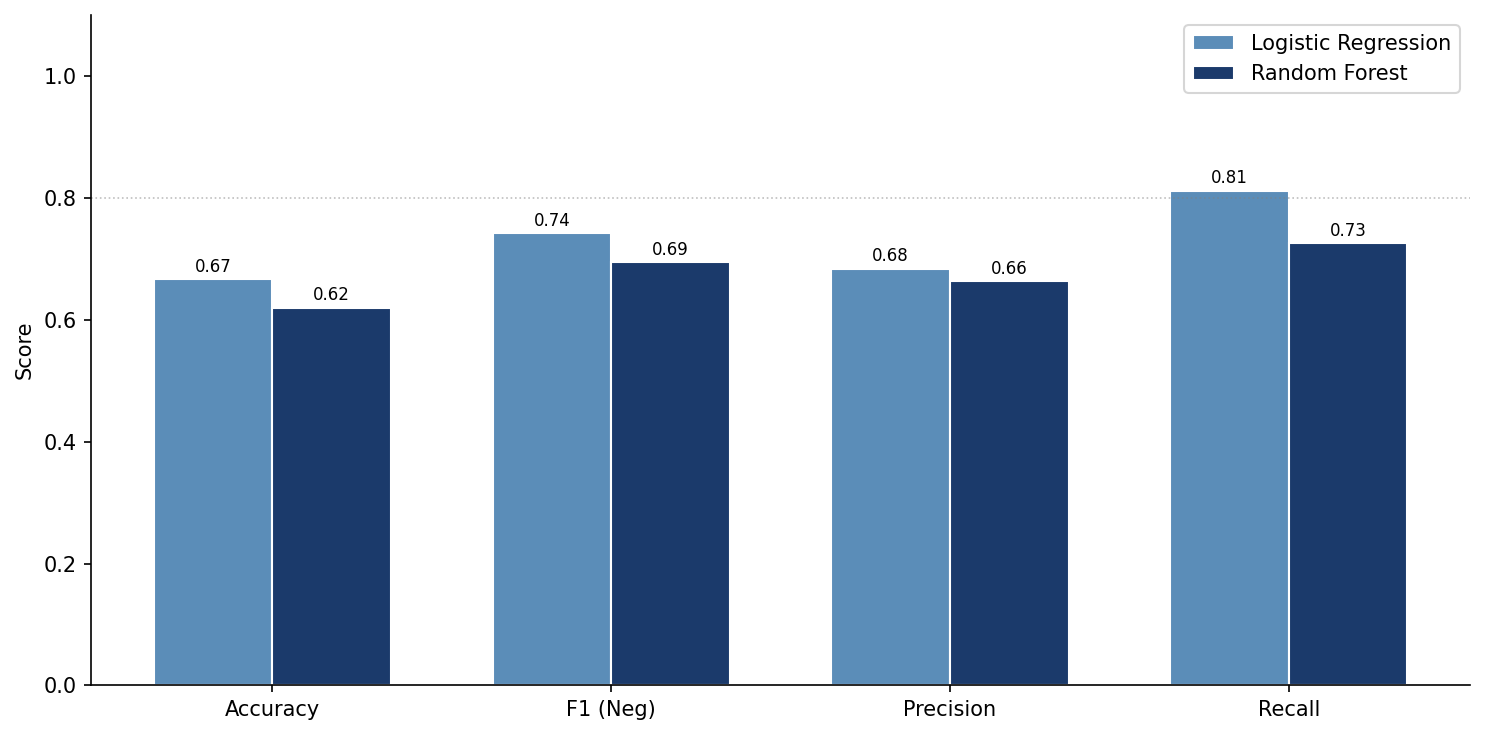

✓ Saved: visuals/fig7_model_comparison.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ── FIGURE 7: Model comparison ────────────────────────
metric_cols = ['Accuracy','F1 (Neg)','Precision','Recall']
x = np.arange(len(metric_cols))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
for i, (model, color) in enumerate(zip(
        ['Logistic Regression','Random Forest'], [BLUE, NAVY])):
    vals = results_df[results_df['Model']==model][metric_cols].values[0]
    bars = ax.bar(x + i*w, vals, w, label=model,
                  color=color, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + w/2)
ax.set_xticklabels(metric_cols)
ax.set_ylim(0, 1.10)
ax.set_ylabel('Score')
#ax.set_title('Figure 7. Supervised Model Performance Comparison',
#             fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(y=0.80, color='grey', linestyle=':', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig('visuals/fig7_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: visuals/fig7_model_comparison.png")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

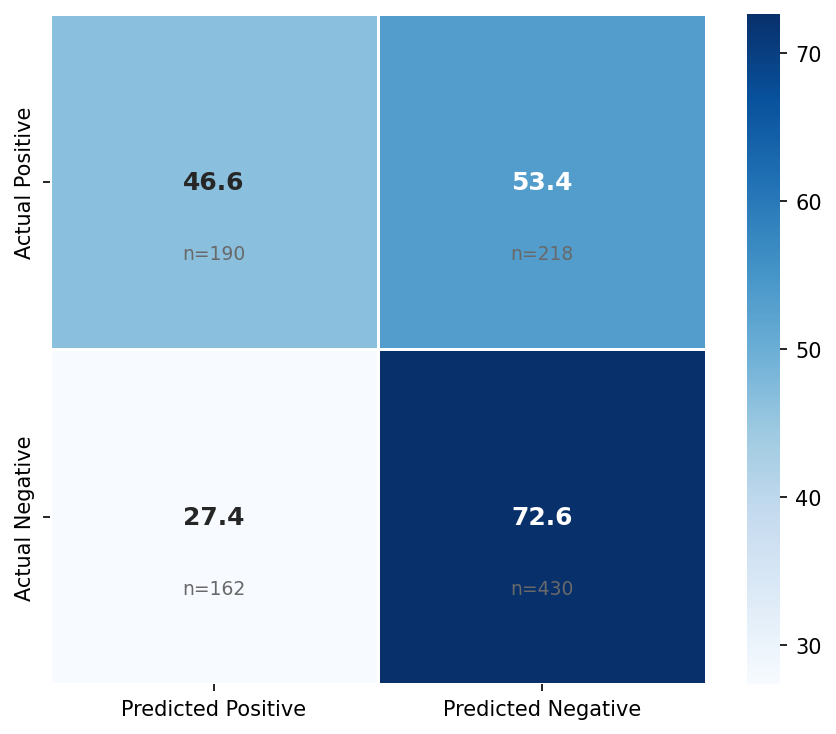

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

✓ Saved: visuals/fig8_confusion_matrix.png

Classification Report — Random Forest:
              precision    recall  f1-score   support

    Positive       0.54      0.47      0.50       408
    Negative       0.66      0.73      0.69       592

    accuracy                           0.62      1000
   macro avg       0.60      0.60      0.60      1000
weighted avg       0.61      0.62      0.61      1000



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ── FIGURE 8: Confusion matrix ────────────────────────
cm     = confusion_matrix(y_test, rf_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Predicted Positive','Predicted Negative'],
            yticklabels=['Actual Positive',  'Actual Negative'],
            linewidths=0.5, ax=ax,
            annot_kws={'size':12, 'weight':'bold'})

for i in range(2):
    for j in range(2):
        ax.text(j+0.5, i+0.73, f'n={cm[i,j]}',
                ha='center', fontsize=9, color='dimgray')

#ax.set_title('Figure 8. Confusion Matrix — Random Forest (%)',
#             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/fig8_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: visuals/fig8_confusion_matrix.png")

print("\nClassification Report — Random Forest:")
print(classification_report(y_test, rf_pred,
      target_names=['Positive','Negative']))

In [ ]:
# ═══════════════════════════════════════════════════════
# STEP 5 — Advanced Analytics: ABSA (keyword-based, no download)
# ═══════════════════════════════════════════════════════

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('visuals', exist_ok=True)

NAVY = '#1B3A6B'
plt.rcParams.update({'figure.dpi':150,'axes.spines.top':False,'axes.spines.right':False})

df = pd.read_csv('data/amazon_reviews_clean.csv')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ── 关键词匹配 aspect 分配 ─────────────────────────────
KEYWORD_MAP = {
    'delivery and shipping'      : ['late','arrived','damaged','shipping',
                                    'never received','transit','delay','dispatch'],
    'product quality and defects': ['broke','defective','stop working','quality',
                                    'broken','failed','cracked','poor'],
    'misleading description'     : ['picture','different','described','fake',
                                    'misleading','expected','advertised','not as'],
    'customer service and returns': ['return','refund','response','contacted',
                                     'support','service','replacement'],
    'safety and health concerns' : ['burn','reaction','dangerous','smell',
                                    'allergic','rash','toxic','hazard'],
    'value for money'            : ['price','expensive','overpriced','worth',
                                    'cheap','cost','value'],
}

def assign_aspect(text):
    text = str(text).lower()
    for aspect, kws in KEYWORD_MAP.items():
        if any(k in text for k in kws):
            return aspect
    return 'product quality and defects'   # default

neg_df = df[df['rating'] <= 2].copy()
neg_df['aspect'] = neg_df['text'].apply(assign_aspect)

aspect_pct = neg_df['aspect'].value_counts(normalize=True) * 100
print("Aspect distribution (%):")
print(aspect_pct.round(1).to_string())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Aspect distribution (%):
aspect
product quality and defects     39.7
misleading description          22.2
delivery and shipping           20.6
customer service and returns     8.8
safety and health concerns       8.7


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

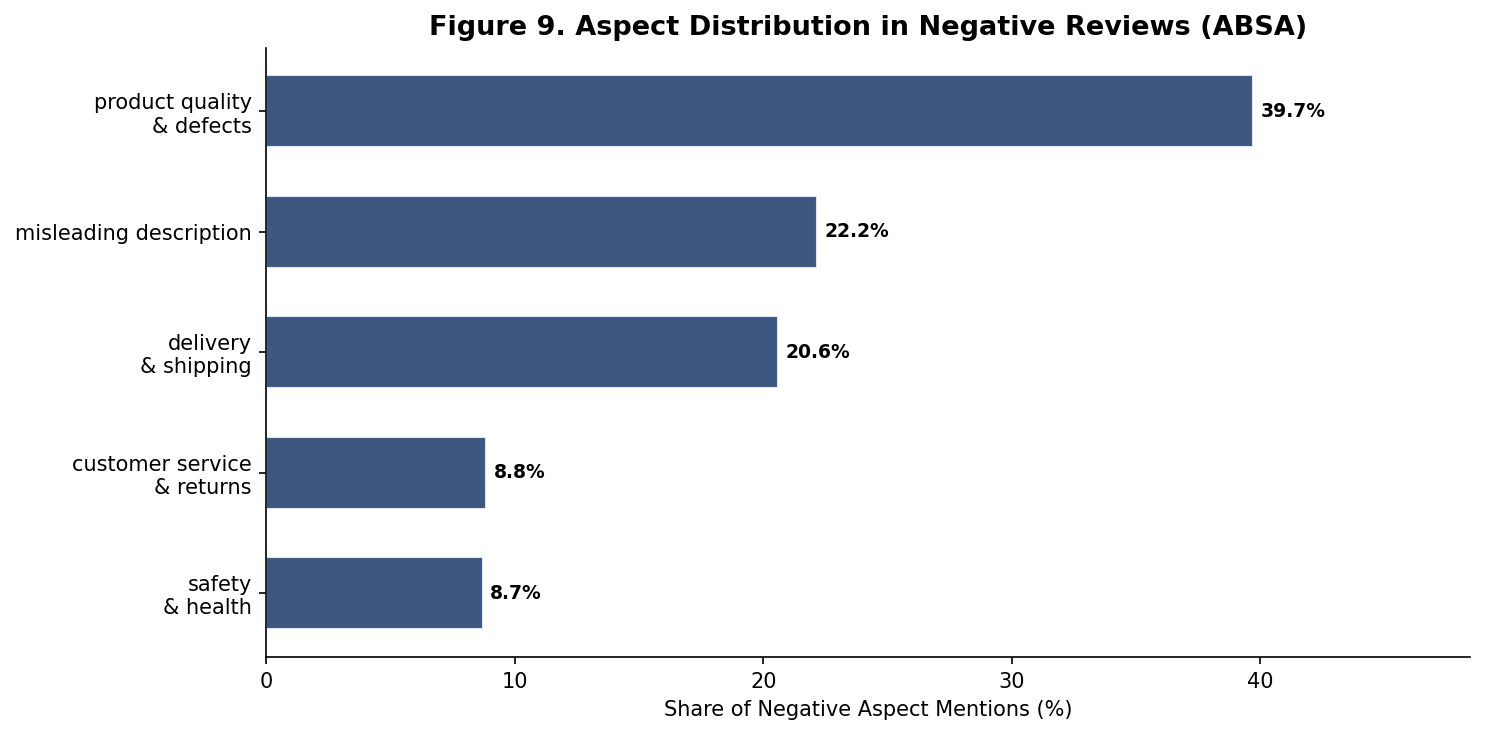

✓ Saved: visuals/fig9_absa_aspects.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ── FIGURE 9: ABSA aspect distribution ───────────────
short_labels = [a.replace(' and ', '\n& ')
                 .replace(' problems','')
                 .replace(' concerns','')
                 for a in aspect_pct.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(short_labels[::-1], aspect_pct.values[::-1],
               color=NAVY, alpha=0.85, edgecolor='white', height=0.6)
ax.set_xlabel('Share of Negative Aspect Mentions (%)')
ax.set_title('Figure 9. Aspect Distribution in Negative Reviews (ABSA)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, aspect_pct.max() * 1.22)

for bar, val in zip(bars, aspect_pct.values[::-1]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('visuals/fig9_absa_aspects.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: visuals/fig9_absa_aspects.png")

In [ ]:
# ── FIGURE 10: Cross-category complaint heatmap ───────
hm_data = (neg_df
           .groupby(['category','aspect'])
           .size()
           .unstack(fill_value=0))
hm_pct = hm_data.div(hm_data.sum(axis=1), axis=0) * 100

hm_pct.columns = [c.replace(' and ', '\n& ')
                   .replace(' problems','')
                   .replace(' concerns','')
                   for c in hm_pct.columns]
hm_pct.index = [i.replace('_and_',' & ').replace('_',' ')
                for i in hm_pct.index]

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(hm_pct, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': '% of Negative Reviews'},
            annot_kws={'size': 9})
ax.set_title('Figure 10. Complaint Theme Distribution by Product Category (%)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Complaint Aspect')
ax.set_ylabel('Category')
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('visuals/fig10_category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: visuals/fig10_category_heatmap.png")